Task-1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [3]:
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Matplotlib Version:", plt.matplotlib.__version__)
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

NumPy Version: 2.3.5
Pandas Version: 2.3.3
Matplotlib Version: 3.10.6
PyTorch Version: 2.11.0
Torchvision Version: 0.26.0


In [4]:
print("MPS Available (Mac GPU):", torch.backends.mps.is_available())

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU ")
else:
    device = torch.device("cpu")
    print("Running on CPU")

print("Selected Device:", device)

# This system uses Apple M2 chip, which does not support CUDA.
# PyTorch uses MPS (Metal Performance Shaders) for GPU acceleration.
# GPU (MPS/CUDA) is faster than CPU because it performs parallel computations.
# On GPU, training can be significantly faster and allows larger batch sizes.

MPS Available (Mac GPU): True
Using Apple MPS GPU
Selected Device: mps


In [5]:
# Reproducibility

torch.manual_seed(42) # torch.manual_seed → controls model weights and operations
np.random.seed(42) # numpy seed → controls NumPy randomness
random.seed(42) # random.seed → controls Python randomness

if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

In [16]:
from torchvision.datasets import MNIST, CIFAR10

mnist_train = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)

cifar_train = CIFAR10(root="./data", train=True, download=True)
cifar_test = CIFAR10(root="./data", train=False, download=True)

In [17]:
import numpy as np

# MNIST
x_train_m = mnist_train.data.numpy()
y_train_m = mnist_train.targets.numpy()

x_test_m = mnist_test.data.numpy()
y_test_m = mnist_test.targets.numpy()

# CIFAR-10
x_train_c = np.array(cifar_train.data)
y_train_c = np.array(cifar_train.targets)

x_test_c = np.array(cifar_test.data)
y_test_c = np.array(cifar_test.targets)

In [18]:
print("MNIST Train Shape:", x_train_m.shape)
print("MNIST Test Shape:", x_test_m.shape)

print("CIFAR Train Shape:", x_train_c.shape)
print("CIFAR Test Shape:", x_test_c.shape)

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)


In [19]:
print("\nMNIST dtype:", x_train_m.dtype)
print("CIFAR dtype:", x_train_c.dtype)


MNIST dtype: uint8
CIFAR dtype: uint8


In [20]:
print("\nMNIST range:", x_train_m.min(), x_train_m.max())
print("CIFAR range:", x_train_c.min(), x_train_c.max())


MNIST range: 0 255
CIFAR range: 0 255


In [21]:
unique, counts = np.unique(y_train_m, return_counts=True)
print("MNIST Class Distribution:")
print(dict(zip(unique, counts)))  
#MNIST class distribution is approximately balanced
# each class has around 6000 samples

MNIST Class Distribution:
{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}


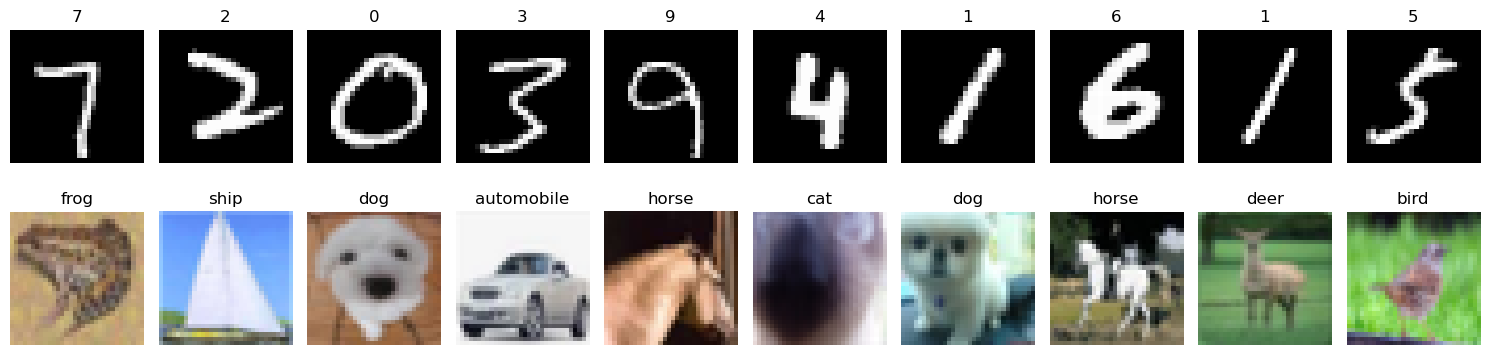

In [22]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# MNIST row
for i in range(10):
    idx = np.random.randint(len(x_train_m))
    axes[0, i].imshow(x_train_m[idx], cmap='gray')
    axes[0, i].set_title(str(y_train_m[idx]))
    axes[0, i].axis('off')

# CIFAR row
classes = cifar_train.classes
for i in range(10):
    idx = np.random.randint(len(x_train_c))
    axes[1, i].imshow(x_train_c[idx])
    axes[1, i].set_title(classes[y_train_c[idx]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [31]:
def preprocessfunc(x, y, is_mnist=False):

    print("BEFORE PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    
    # Normalize to [0, 1]
    x = x.astype(np.float32) / 255.0  # Pixel values are scaled to the range [0,1] by dividing by 255.0.
     # This helps in faster convergence and stable training of neural networks.
    
    # Reshape MNIST (add channel dimension)
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
    
    # One-hot encode labels(Labels are converted into vectors of length 10, where the correct class index is 1 and others are 0.)
    y_onehot = np.eye(10)[y]
    
    print("\nAFTER PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    print("Label sample (one-hot):", y_onehot[0])
    
    return x, y_onehot

In [32]:
x_train_m_p, y_train_m_p = preprocessfunc(x_train_m, y_train_m, is_mnist=True)

BEFORE PREPROCESSING
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255
Sample values: [0 0 0 0 0 0 0 0 0 0]

AFTER PREPROCESSING
Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Label sample (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [33]:
x_train_c_p, y_train_c_p = preprocessfunc(x_train_c, y_train_c, is_mnist=False)

BEFORE PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: uint8
Min/Max: 0 255
Sample values: [59 62 63 43 46 45 50 48 43 68]

AFTER PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0.23137255 0.24313726 0.24705882 0.16862746 0.18039216 0.1764706
 0.19607843 0.1882353  0.16862746 0.26666668]
Label sample (one-hot): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [34]:
cifar_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(32, scale=(0.9, 1.1)),
    transforms.ToTensor()
])

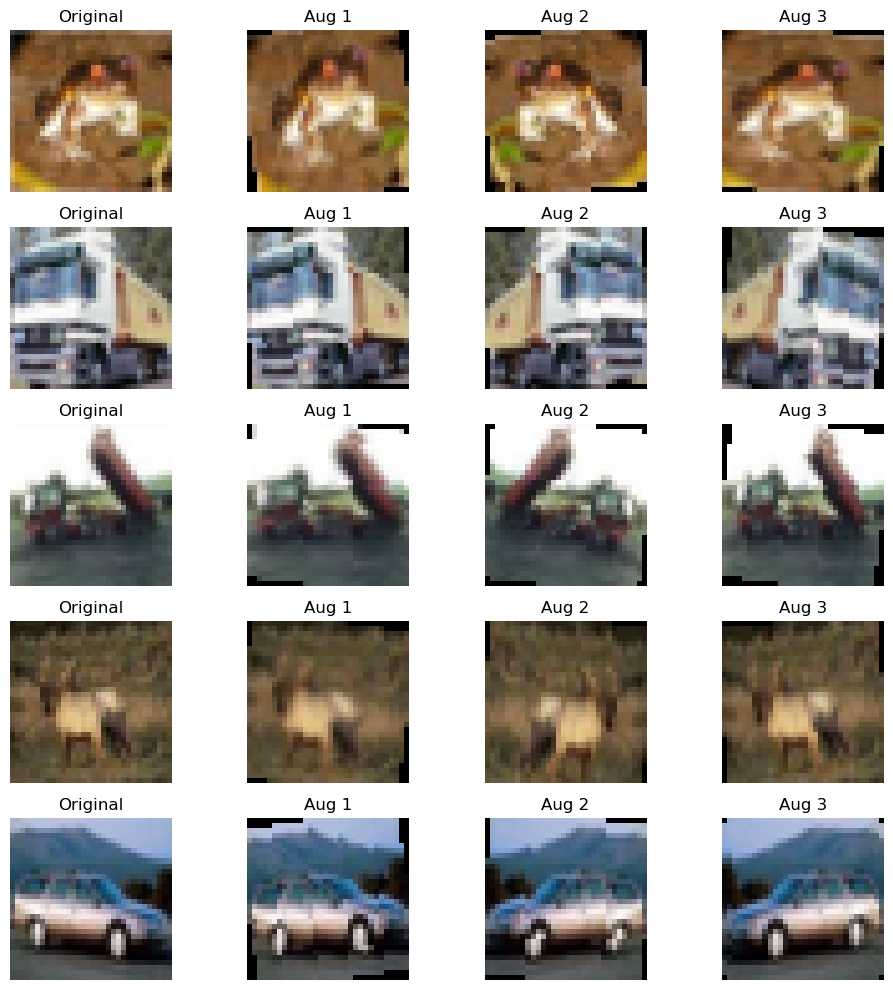

In [35]:
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for i in range(5):
    img = x_train_c[i]

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented
    for j in range(1, 4):
        aug_img = cifar_transform(img)
        aug_img = aug_img.permute(1, 2, 0)

        axes[i, j].imshow(aug_img)
        axes[i, j].set_title(f"Aug {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set to increase data diversity and improve the model’s ability to generalize. It introduces variations such as rotation, flipping, and zoom, which help reduce overfitting.

The validation and test sets must remain unchanged because they are used to evaluate the model on real, unseen data. Applying augmentation to them would distort the data distribution and result in biased or unreliable evaluation.

Augmentation must be label-preserving, meaning the transformation should not change the class of the image.

For MNIST : digits are sensitive to orientation. Transformations like horizontal flipping are not suitable because flipping a digit such as “6” may resemble a “9”, thereby changing its label. Therefore, only safe transformations like small rotations are applied.

For CIFAR-10 : objects such as animals and vehicles remain identifiable even after transformations like horizontal flipping, rotation, and zoom. Hence, these augmentations are valid and do not alter the class label.

Thus, different augmentation strategies are used for MNIST and CIFAR-10 to ensure that all transformations are label-preserving. This helps maintain data integrity while improving model generalization.

In [36]:
mnist_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),   # small rotation only
    transforms.ToTensor()
])

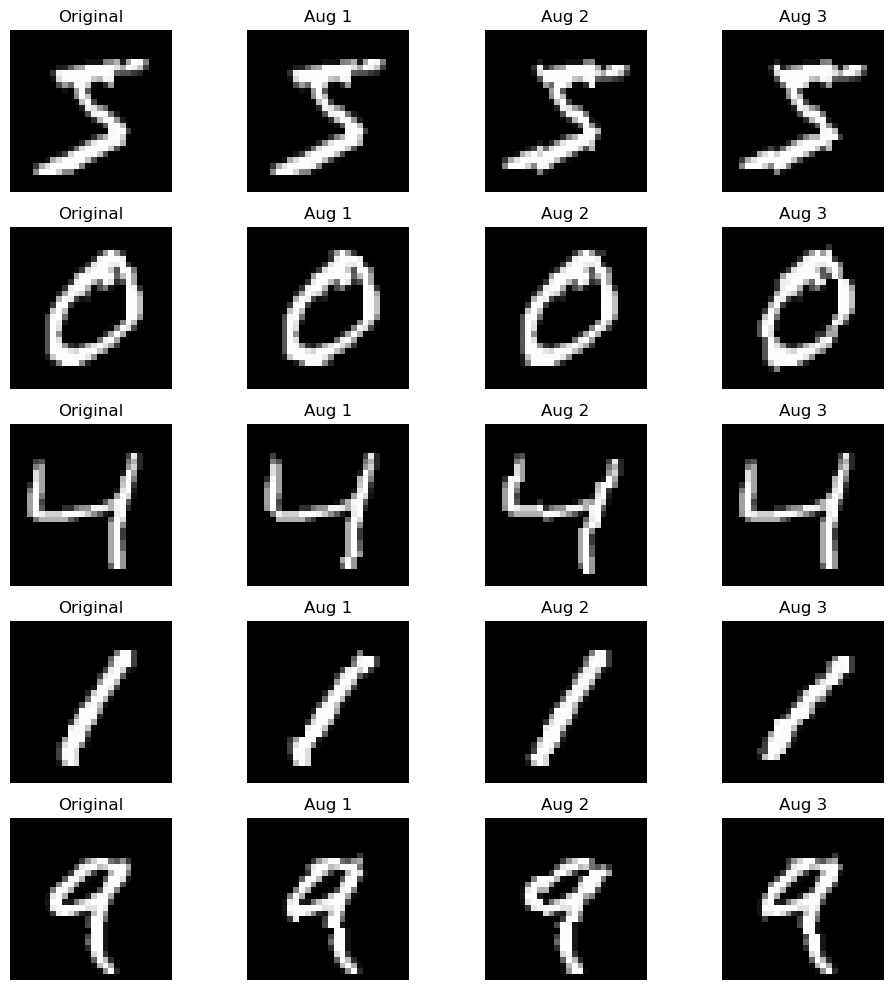

In [37]:
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for i in range(5):
    img = x_train_m[i]   

    # Original
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented versions
    for j in range(1, 4):
        aug_img = mnist_transform(img)   # apply transform
        aug_img = aug_img.squeeze()      # remove channel dim
        
        axes[i, j].imshow(aug_img, cmap='gray')
        axes[i, j].set_title(f"Aug {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("mnist_augmentation_demo.png")
plt.show()

ANALYSIS & REFLECTION QUESTIONS (Task-1)

1. The channel dimension C in a tensor of shape (N, H, W, C) represents the      number of feature channels or color components present in each image.
   N = number of images (batch size)
   H = height of image
   W = width of image
   C = number of channels

For a greyscale image, there is only one channel (C = 1).
This channel stores intensity values (brightness) for each pixel.

For an RGB image, there are three channels (C = 3): Red, Green & Blue channels 

2. To handle very large images (1024×1024) without running out of memory, the    following strategies can be used:

Batch Loading (DataLoader):
Instead of loading the entire dataset into memory, images are loaded in small batches during training. This reduces memory usage and allows efficient processing.

Patch-based Training:
Large images are divided into smaller patches (e.g., 256×256). The model is trained on these patches instead of the full image, significantly reducing memory requirements

Additionally, image resizing or downsampling can also be used to reduce resolution, but this may lead to loss of fine details.

3. Applying normalization to the test set using its own mean and standard        deviation is incorrect because it introduces data leakage.

The test set is supposed to represent unseen data. Using its statistics allows the model to indirectly gain information about the test distribution, leading to biased and overly optimistic evaluation results.

Instead, the test set must be normalized using the mean and standard deviation computed from the training set only, ensuring a fair and realistic evaluation.

Task-2

In [40]:
# Given 5x5 image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

In [41]:
def conv2d(image, kernel, stride=1, padding=0):
    
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    
    H, W = image.shape
    kH, kW = kernel.shape
    
    # Output size
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    
    output = np.zeros((out_H, out_W))
    
    # Convolution operation
    for i in range(out_H):
        for j in range(out_W):
            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(patch * kernel)
    
    return output

In [42]:
output = conv2d(image, kernel, stride=1, padding=0)
print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Output Size Derivation :

Formula:

output = [(input - kernal + 2 * padding)/stride] + 1

(a) Input: 28×28, Kernel: 5×5, Padding: 0 (valid), Stride: 1

  output = (28 - 5 + 0)/1 + 1 = 24 

(b) Input: 28×28, Kernel: 3×3, Padding: 1 (same), Stride: 1

output = (28 - 3 + 2*1)/1 +1 = 28

(c) Input: 32×32, Kernel: 3×3, Padding: 0 (valid), Stride: 2

output = (32 - 3 + 0)/2 +1 = 15

(d) Two consecutive Conv2D layers: first with K=3, P=1, S=1 applied to 32×32; then K=3, P=0, S=1 applied to the output. What is the final size?

first layer => (32−3+2)/1+1=32  , second layer => (32−3)/1+1=30

final output = 30

In [43]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # Conv layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)   
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)                     
        self.conv2 = nn.Conv2d(6, 16, 5)                                      
        
        # Fully connected layers
        self.fc1 = nn.Linear(16*4*4, 120)   # flatten
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)
        
        x = torch.tanh(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)   # flatten
        
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # softmax applied in loss
        
        return x

In [44]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [46]:
!pip install torchsummary

In [47]:
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
         AvgPool2d-2            [-1, 6, 12, 12]               0
            Conv2d-3             [-1, 16, 8, 8]           2,416
         AvgPool2d-4             [-1, 16, 4, 4]               0
            Linear-5                  [-1, 120]          30,840
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.17
Estimated Total Size (MB): 0.22
----------------------------------------------------------------


Manually calculate the parameter count for the first Conv2D layer only

Formula : (K × K × C_in + 1) × C_out
k=5, c_in=1, c_out=6

(5×5×1+1)×6 = (25+1)×6 = 26×6 = 156

AvgPooling was used in LeNet-5 because early CNNs focused on smooth feature extraction and noise reduction. It computes the average of values in a region, preserving overall information.

In modern CNNs, MaxPooling is more common because it captures the most prominent features (strong activations), improves feature selectivity, and works better for complex tasks like object recognition.

Full Architecture Flow

Conv1 → 24×24×6
Pool → 12×12×6
Conv2 → 8×8×16
Pool → 4×4×16
Flatten → 256
FC1 → 120
FC2 → 84
Output → 10

ASCII DIAGRAM : 

Input: 32×32×3

[Conv(32) → BN → ReLU → Pool] → 16×16×32
[Conv(64) → BN → ReLU → Pool] → 8×8×64
[Conv(128) → BN → ReLU → Pool] → 4×4×128

Flatten → 2048
Dense(256) → ReLU → Dropout
Dense(10)

The architecture uses three convolutional blocks to progressively extract hierarchical features from CIFAR-10 images. Batch Normalization is applied after each convolution to stabilize training and improve convergence. MaxPooling reduces spatial dimensions while retaining important features. A fully connected head with Dropout is used to prevent overfitting and improve generalization.

In [48]:
# CNN from scratch

import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),   
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)   # Flatten
        x = self.fc_layers(x)
        return x

In [49]:
from torchsummary import summary
model = CNN()
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,496
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
         MaxPool2d-8             [-1, 64, 8, 8]               0
            Conv2d-9            [-1, 128, 8, 8]          73,856
      BatchNorm2d-10            [-1, 128, 8, 8]             256
             ReLU-11            [-1, 128, 8, 8]               0
        MaxPool2d-12            [-1, 128, 4, 4]               0
           Linear-13                  [-1, 256]         524,544
             ReLU-14                  [

ANALYSIS & REFLECTION QUESTIONS ( task - 2)

1. For same input channels C and filter F:
   One 5×5 Conv: (25C+1)F
   Two 3×3 Conv: (9C+1)F+(9F+1)F

   Numerical Example (C = F = 64)
   -> 5×5 Conv = 102,464 parameters
   -> Two 3×3 Conv = 73,856 parameters

   Fewer parameters → reduces overfitting
   More non-linearity (extra activation layer)

->Two stacked 3×3 convolution layers are more efficient and perform         better than a single 5×5 layer.


2. Batch Normalisation (BatchNorm) normalises the activations of a layer by maintaining a stable mean and variance during training. This helps in stabilising and accelerating the learning process.

BatchNorm is typically placed after the convolution layer and before the activation function (Conv → BN → ReLU). This is because it normalises the input to the activation, leading to more stable and effective non-linear transformations.

Empirical Benefits :
Faster convergence during training
Reduces internal covariate shift
Allows use of higher learning rates
Acts as a form of regularisation, reducing overfitting

3. Global Average Pooling (GAP) reduces each feature map to a single value by taking the average over all spatial locations. Geometrically, it converts a feature map of size H×W×C into a vector of size 1×1×C, preserving only channel-wise information.

If GAP is replaced with Flatten, the entire spatial structure H×W×C is converted into a long vector. This significantly increases the number of parameters in the Dense layers, leading to higher computational cost and risk of overfitting.

Task - 3

In [50]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Split 90% train, 10% validation
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [51]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = LeNet5().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [53]:
# Training

train_losses, val_losses = [], []
train_accs, val_accs = [], []  

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)
    
    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)
    
    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")

Epoch 1: Train Loss=2.0088, Val Loss=1.1562
Epoch 2: Train Loss=0.7265, Val Loss=0.5284
Epoch 3: Train Loss=0.4414, Val Loss=0.3994
Epoch 4: Train Loss=0.3553, Val Loss=0.3378
Epoch 5: Train Loss=0.3070, Val Loss=0.2952
Epoch 6: Train Loss=0.2703, Val Loss=0.2615
Epoch 7: Train Loss=0.2395, Val Loss=0.2331
Epoch 8: Train Loss=0.2129, Val Loss=0.2062
Epoch 9: Train Loss=0.1902, Val Loss=0.1841
Epoch 10: Train Loss=0.1709, Val Loss=0.1677
Epoch 11: Train Loss=0.1549, Val Loss=0.1529
Epoch 12: Train Loss=0.1415, Val Loss=0.1405
Epoch 13: Train Loss=0.1303, Val Loss=0.1316
Epoch 14: Train Loss=0.1211, Val Loss=0.1230
Epoch 15: Train Loss=0.1131, Val Loss=0.1147


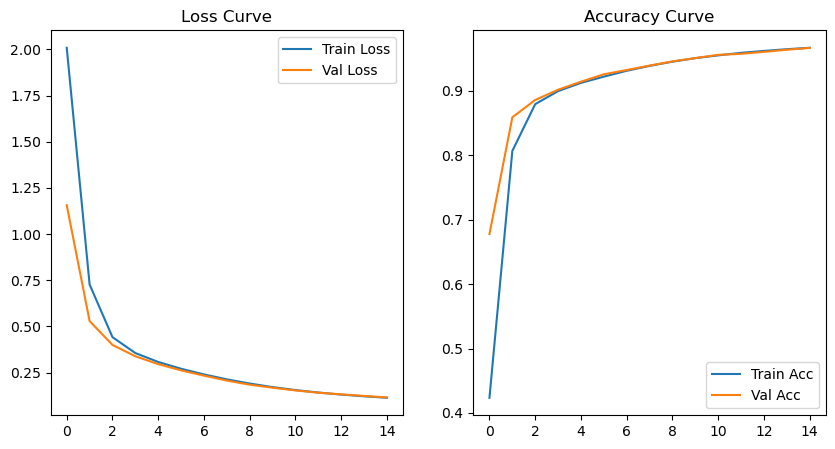

In [58]:
plt.figure(figsize=(10,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()

plt.savefig("lenet_sgd_curves.png")
plt.show()

In [59]:
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64)

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9689


-> The model does not show clear signs of overfitting within 15 epochs, as both training and validation loss decrease together and remain close. This indicates good generalization.

-> The model achieves high accuracy on MNIST, indicating that LeNet-5 is well-suited for simple grayscale image classification tasks.

In [60]:
# Optimiser Comparison

def train_model(optimizer_name):
    
    model = LeNet5().to(device)
    
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    criterion = nn.CrossEntropyLoss()
    
    val_accs = []
    
    for epoch in range(15):
        model.train()
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        correct, total = 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                _, predicted = outputs.max(1)
                
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        
        val_accs.append(correct / total)
    
    return val_accs

In [61]:
sgd_acc = train_model("SGD")
momentum_acc = train_model("Momentum")
adam_acc = train_model("Adam")

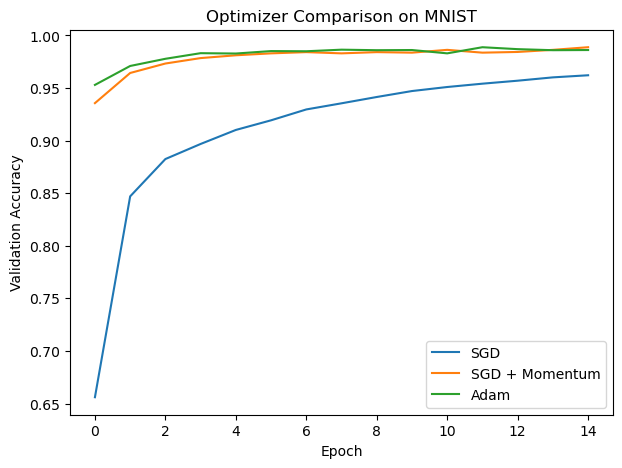

In [62]:
plt.figure(figsize=(7,5))

plt.plot(sgd_acc, label="SGD")
plt.plot(momentum_acc, label="SGD + Momentum")
plt.plot(adam_acc, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison on MNIST")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

Observations :
SGD shows slow convergence, with validation accuracy increasing gradually and reaching around 96% after 15 epochs.
SGD with momentum converges much faster than plain SGD and achieves high accuracy early (≈97–98%).
Adam converges the fastest and reaches high accuracy within the first few epochs, maintaining stable performance throughout training.

Comparison :
SGD has the slowest learning speed
Momentum improves SGD by accelerating convergence
Adam performs best due to adaptive learning rates

Adam is the most efficient optimizer for this task as it achieves high accuracy quickly and remains stable. SGD with momentum also performs well and is better than plain SGD. Basic SGD is the least efficient due to slower convergence.

Training custom CIFAR-10 CNN

In [63]:
def train_cifar(lr, batch_size):
    
    # DataLoader 
    train_loader = DataLoader(train_dataset_cifar, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset_cifar, batch_size=batch_size)
    
    # NEW model every time 
    model = CNN().to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(10):
        model.train()
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    # Validation accuracy
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return correct / total

In [65]:
from torchvision.datasets import CIFAR10
from torch.utils.data import random_split, DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

# Load full dataset
dataset_cifar = CIFAR10(root="./data", train=True, download=True, transform=transform)

# Split 90% train, 10% validation
train_size = int(0.9 * len(dataset_cifar))
val_size = len(dataset_cifar) - train_size

train_dataset_cifar, val_dataset_cifar = random_split(dataset_cifar, [train_size, val_size])

In [66]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Running LR={lr}, Batch={bs}")
        acc = train_cifar(lr, bs)
        results[(lr, bs)] = acc

Running LR=0.1, Batch=32
Running LR=0.1, Batch=128
Running LR=0.01, Batch=32
Running LR=0.01, Batch=128
Running LR=0.001, Batch=32
Running LR=0.001, Batch=128


In [67]:
print("\nFinal Validation Accuracy Table:\n")

for lr in learning_rates:
    row = []
    for bs in batch_sizes:
        row.append(f"{results[(lr, bs)]:.4f}")
    print(f"LR={lr}:  {row}")


Final Validation Accuracy Table:

LR=0.1:  ['0.7424', '0.7296']
LR=0.01:  ['0.7142', '0.6806']
LR=0.001:  ['0.6354', '0.5108']


Observation :
LR = 0.1 → too high → unstable training
LR = 0.001 → too low → slow learning
LR = 0.01 → best performance
Batch size 32 performs slightly better than 128 due to more frequent updates

Learning rate = 0.01, Batch size = 32
It provides a good balance between convergence speed and stability.